In [1]:
# Section 0 - Settings
from pathlib import Path

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yaml

pd.set_option("display.max_columns", None)
plt.rcParams.update({"figure.dpi": 120})

csv_path = "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/inference/first_category/exp003/inference/inference_predictions.csv"
pipeline_config_path = "/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/inference/first_category/exp003/inference/pipeline_config.yml"
output_dir = Path("/project/def-nahee/kbas/Graphnet-Applications/Results/340StringMC/full_geometry_emax1e6/inference/first_category/exp003/inference")

df = pd.read_csv(csv_path)
if "true_log10_energy" not in df.columns and "true_energy" in df.columns:
    df["true_log10_energy"] = np.log10(df["true_energy"])
with open(pipeline_config_path) as f:
    pipeline_cfg = yaml.safe_load(f)
with open(pipeline_cfg["classification"]["config"]) as f:
    classification_cfg = yaml.safe_load(f)

task_cfg = classification_cfg["task"]
class_labels = [int(label) for label in task_cfg["labels"]]
raw_class_names = task_cfg.get("class_names", {}) or {}
class_names = {int(k): str(v) for k, v in raw_class_names.items()}

true_class_col = "true_classification_class"
pred_class_col = "predicted_route_class"
analysis_group_col = "_pid_interaction_group"
pid_interaction_exact_col = "_pid_interaction_exact_group"
confusion_route_col = "_confusion_route_group"

def class_label(value):
    if pd.isna(value):
        return "missing"
    value = int(value)
    return class_names.get(value, f"class {value}")

def particle_label(pid):
    if pd.isna(pid):
        return "pid missing"
    pid_int = int(pid)
    names = {12: "electron", 14: "muon", 16: "tau"}
    return names.get(abs(pid_int), f"pid {abs(pid_int)}")

def interaction_label(value):
    if pd.isna(value):
        return "interaction missing"
    value_int = int(value)
    names = {1: "CC", 2: "NC"}
    return names.get(value_int, f"interaction {value_int}")

def pid_interaction_group(pid, interaction_type):
    interaction = interaction_label(interaction_type)
    if interaction == "NC":
        return "NC"
    return f"{particle_label(pid)} {interaction}"

def pid_interaction_exact_group(pid, interaction_type):
    return f"{particle_label(pid)} {interaction_label(interaction_type)}"

if {"pid", "interaction_type"}.issubset(df.columns):
    df[analysis_group_col] = [pid_interaction_group(pid, interaction_type) for pid, interaction_type in zip(df["pid"], df["interaction_type"])]
    df[pid_interaction_exact_col] = [pid_interaction_exact_group(pid, interaction_type) for pid, interaction_type in zip(df["pid"], df["interaction_type"])]

if {true_class_col, pred_class_col}.issubset(df.columns):
    df[confusion_route_col] = [
        f"true {class_label(true_value)} -> pred {class_label(pred_value)}"
        for true_value, pred_value in zip(df[true_class_col], df[pred_class_col])
    ]

def group_label(key):
    return str(key)

def sigma68(values):
    values = pd.Series(values).replace([np.inf, -np.inf], np.nan).dropna()
    if len(values) == 0:
        return np.nan
    return 0.5 * (np.percentile(values, 84) - np.percentile(values, 16))

def binned_sigma(frame, x_col, residual_col, bins):
    work = frame[[x_col, residual_col]].replace([np.inf, -np.inf], np.nan).dropna().copy()
    if work.empty:
        return pd.DataFrame(columns=["bin_center", "sigma68", "count"])
    work["bin"] = pd.cut(work[x_col], bins=bins, include_lowest=True)
    out = (
        work.groupby("bin", observed=True)[residual_col]
        .agg(count="count", sigma68=sigma68)
        .reset_index()
    )
    out["bin_center"] = out["bin"].map(lambda item: item.mid).astype(float)
    return out

def subplot_grid(n_items, width=5.2, height=4.2):
    ncols = min(2, max(1, n_items))
    nrows = int(math.ceil(n_items / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(width * ncols, height * nrows), squeeze=False)
    return fig, axes.ravel()

def grouped_frames(frame):
    if analysis_group_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[analysis_group_col]).groupby(analysis_group_col, sort=True))

def class_grouped_frames(frame):
    if true_class_col not in frame.columns:
        return []
    groups = []
    for key, group in frame.dropna(subset=[true_class_col]).groupby(true_class_col, sort=True):
        groups.append((class_label(key), group))
    return groups

def pid_interaction_grouped_frames(frame):
    if pid_interaction_exact_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[pid_interaction_exact_col]).groupby(pid_interaction_exact_col, sort=True))

def confusion_route_grouped_frames(frame):
    if confusion_route_col not in frame.columns:
        return []
    return list(frame.dropna(subset=[confusion_route_col]).groupby(confusion_route_col, sort=True))

def plot_resolution_and_residual_groups(frame, groups, residual_col, y_label, residual_xlabel, title_prefix, color="tab:blue", hist_bins=80):
    groups = [(label, group.replace([np.inf, -np.inf], np.nan).dropna(subset=["true_log10_energy", residual_col])) for label, group in groups]
    groups = [(label, group) for label, group in groups if not group.empty]
    if not groups:
        print(f"No groups available for {title_prefix}.")
        return None

    fig, axes = plt.subplots(len(groups), 2, figsize=(13, 4.2 * len(groups)), squeeze=False)
    for row, (label, group) in enumerate(groups):
        ax_res, ax_hist = axes[row]

        table = binned_sigma(group, "true_log10_energy", residual_col, bins)
        ax_res.plot(table["bin_center"], table["sigma68"], marker="o", linewidth=2, color=color)
        ax_res.set_title(f"{title_prefix} resolution - {label}")
        ax_res.set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
        ax_res.set_ylabel(y_label)
        ax_res.grid(True, alpha=0.3)

        ax_hist.hist(group[residual_col], bins=hist_bins, histtype="stepfilled", alpha=0.75, color=color)
        ax_hist.axvline(0, color="black", linestyle="--", linewidth=1)
        ax_hist.set_title(f"{title_prefix} residuals - {label}")
        ax_hist.set_xlabel(residual_xlabel)
        ax_hist.set_ylabel("Events")
        ax_hist.grid(True, alpha=0.2)

    fig.tight_layout()
    plt.show()
    return None

df.head()


,event_key,event_no,RunID,SubrunID,EventID,SubEventID,position_x,position_y,position_z,pid,interaction_type,totalEnergy,zenith,azimuth,finalStateX,finalStateY,finalType1,finalType2,initialType,totalColumnDepth,impactParameter,fully_contained,starting_track,stopping_track,through_going,missed_track,true_classification_class,predicted_route_class,p_class_0,p_class_1,true_energy,true_log10_energy,pred_energy,pred_log10_energy,true_zenith_radian,pred_zenith_radian,true_zenith_degree,pred_zenith_degree,residual_zenith_degree,zenith_kappa,true_azimuth_radian,pred_azimuth_radian,true_azimuth_degree,pred_azimuth_degree,residual_azimuth_degree,azimuth_kappa,pred_azimuth_degree_signed,_pid_interaction_group,_pid_interaction_exact_group,_confusion_route_group
0,158:8:4294967295:153:0,158.0,8.0,4.294967e+09,153.0,0.0,-2008.307248,-1451.026642,-791.656878,-14.0,1.0,9447.432947,1.952724,3.779391,0.331857,0.008863,-13.0,-2.000001e+09,-14.0,1.414673e+06,191.137888,0.0,0.0,0.0,1.0,0.0,1.0,1,0.077039,0.922961,9447.432947,3.975314,5137.04800,3.710714,1.952724,1.943167,111.882850,111.335236,-0.547617,97.001150,3.779391,3.810812,216.54315,218.34344,1.800288,96.92736,-141.656560,muon CC,muon CC,true muon_CC -> pred muon_CC
1,467:0:4294967295:129:0,467.0,0.0,4.294967e+09,129.0,0.0,-410.789565,-858.124860,-170.482651,-14.0,1.0,204.707767,1.399111,3.914233,0.043672,0.271836,-13.0,-2.000001e+09,-14.0,3.230936e+05,458.444983,0.0,0.0,1.0,0.0,0.0,1.0,1,0.094792,0.905208,204.707767,2.311134,350.71652,2.544956,1.399111,1.431933,80.163150,82.043730,1.880583,98.534170,3.914233,3.908166,224.26903,223.92140,-0.347643,81.69262,-136.078610,muon CC,muon CC,true muon_CC -> pred muon_CC
2,540:19:4294967295:47:0,540.0,19.0,4.294967e+09,47.0,0.0,-1818.735028,398.918951,-603.445068,14.0,1.0,3224.352940,1.749122,2.940091,0.035983,0.161111,13.0,-2.000001e+09,14.0,9.710170e+05,264.992480,0.0,0.0,0.0,1.0,0.0,1.0,1,0.077722,0.922278,3224.352940,3.508443,3835.62040,3.583836,1.749122,1.745298,100.217320,99.998190,-0.219126,100.280876,2.940091,2.951487,168.45477,169.10774,0.652952,96.53407,169.107740,muon CC,muon CC,true muon_CC -> pred muon_CC
3,568:16:4294967295:75:0,568.0,16.0,4.294967e+09,75.0,0.0,-196.080406,227.610178,1110.526772,14.0,1.0,630.220722,0.604156,4.285788,0.117514,0.271006,13.0,-2.000001e+09,14.0,3.233213e+05,783.591862,0.0,0.0,0.0,1.0,0.0,1.0,1,0.109158,0.890842,630.220722,2.799493,795.69403,2.900746,0.604156,0.731280,34.615616,41.899258,7.283642,96.160650,4.285788,4.484848,245.55754,256.96286,11.405323,68.50347,-103.037130,muon CC,muon CC,true muon_CC -> pred muon_CC
4,1043:27:4294967295:152:0,1043.0,27.0,4.294967e+09,152.0,0.0,822.374464,13.188523,717.873200,-14.0,1.0,10121.362925,1.257949,5.712029,0.217223,0.581274,-13.0,-2.000001e+09,-14.0,6.683217e+05,656.278604,0.0,0.0,0.0,1.0,0.0,1.0,1,0.096378,0.903622,10121.362925,4.005239,10546.50300,4.023109,1.257948,1.263984,72.075140,72.420975,0.345833,98.212700,5.712029,5.702256,327.27512,326.71520,-0.559939,95.48658,-33.284782,muon CC,muon CC,true muon_CC -> pred muon_CC


## Section 1 - Confusion Matrix


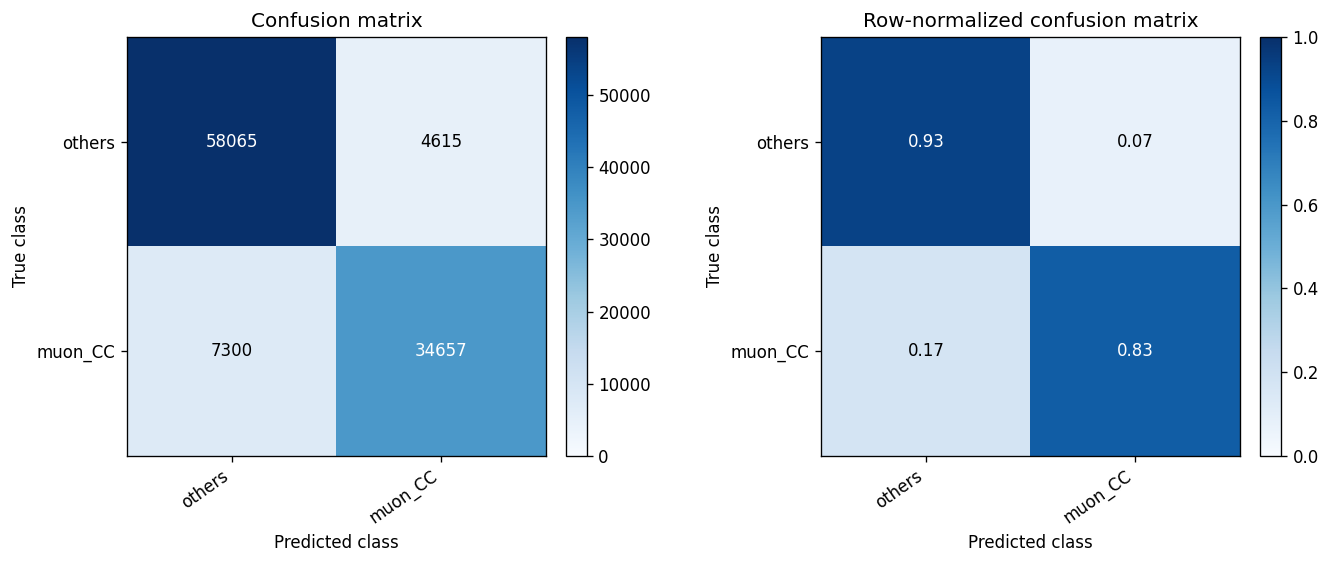

,others,muon_CC
others,58065,4615
muon_CC,7300,34657


In [2]:
def confusion_table(frame):
    work = frame[[true_class_col, pred_class_col]].dropna().copy()
    work[true_class_col] = work[true_class_col].astype(int)
    work[pred_class_col] = work[pred_class_col].astype(int)
    names = [class_label(label) for label in class_labels]
    table = pd.crosstab(work[true_class_col], work[pred_class_col]).reindex(
        index=class_labels, columns=class_labels, fill_value=0
    )
    table.index = names
    table.columns = names
    return table

cm_counts = confusion_table(df)
cm_norm = cm_counts.div(cm_counts.sum(axis=1).replace(0, np.nan), axis=0).fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.8))
for ax, table, title, fmt, vmax in [
    (axes[0], cm_counts, "Confusion matrix", "d", None),
    (axes[1], cm_norm, "Row-normalized confusion matrix", ".2f", 1),
]:
    im = ax.imshow(table.values, cmap="Blues", vmin=0, vmax=vmax)
    ax.set_xticks(np.arange(len(table.columns)), labels=table.columns, rotation=35, ha="right")
    ax.set_yticks(np.arange(len(table.index)), labels=table.index)
    ax.set_xlabel("Predicted class")
    ax.set_ylabel("True class")
    ax.set_title(title)
    threshold = np.nanmax(table.values) / 2 if table.values.size else 0
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table.iloc[i, j]
            ax.text(j, i, format(value, fmt), ha="center", va="center", color="white" if value > threshold else "black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

cm_counts


## Section 2 - Energy


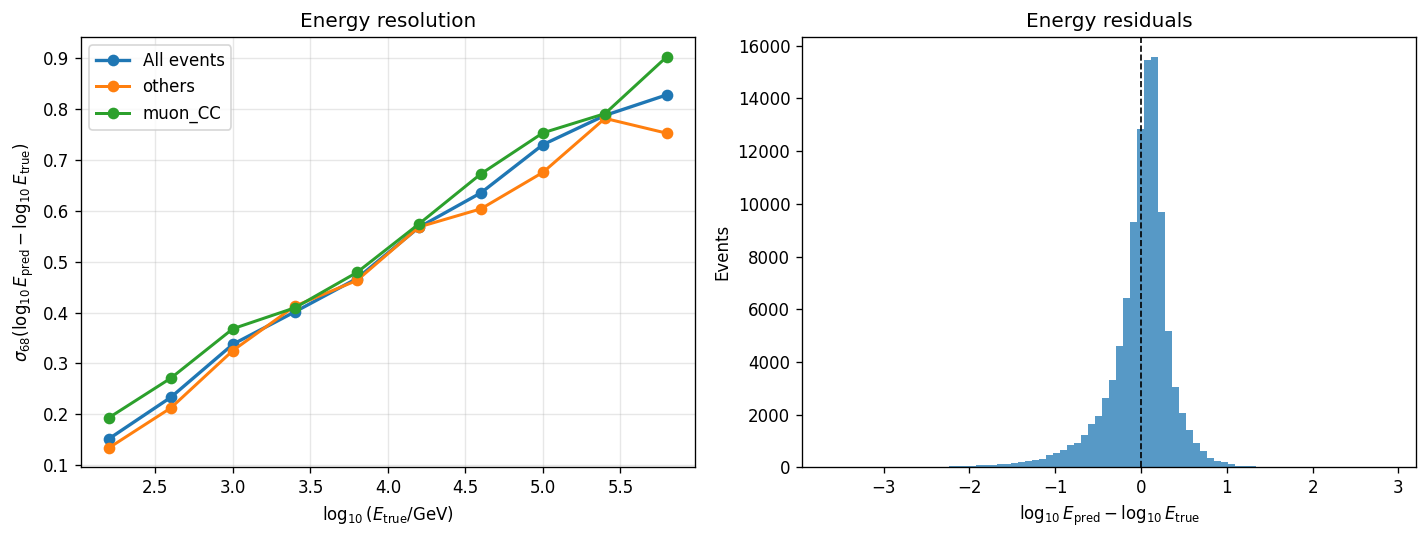

,count,median,mean,sigma68
0,104637,0.048742,-0.016337,0.268127


In [3]:
energy_needed = ["true_energy", "true_log10_energy", "pred_energy", "pred_log10_energy", true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
energy_df = df[[col for col in energy_needed if col in df.columns]].dropna().copy()
energy_df = energy_df[(energy_df["true_energy"] > 0) & (energy_df["pred_energy"] > 0)]
energy_df["energy_residual_log10"] = energy_df["pred_log10_energy"] - energy_df["true_log10_energy"]
bins = np.linspace(energy_df["true_log10_energy"].min(), energy_df["true_log10_energy"].max(), 11)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(energy_df, "true_log10_energy", "energy_residual_log10", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in energy_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "energy_residual_log10", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"$\sigma_{68}(\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true})$")
axes[0].set_title("Energy resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(energy_df["energy_residual_log10"], bins=80, histtype="stepfilled", alpha=0.75)
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$")
axes[1].set_ylabel("Events")
axes[1].set_title("Energy residuals")
fig.tight_layout()
plt.show()

pd.DataFrame({
    "count": [len(energy_df)],
    "median": [energy_df["energy_residual_log10"].median()],
    "mean": [energy_df["energy_residual_log10"].mean()],
    "sigma68": [sigma68(energy_df["energy_residual_log10"])],
})


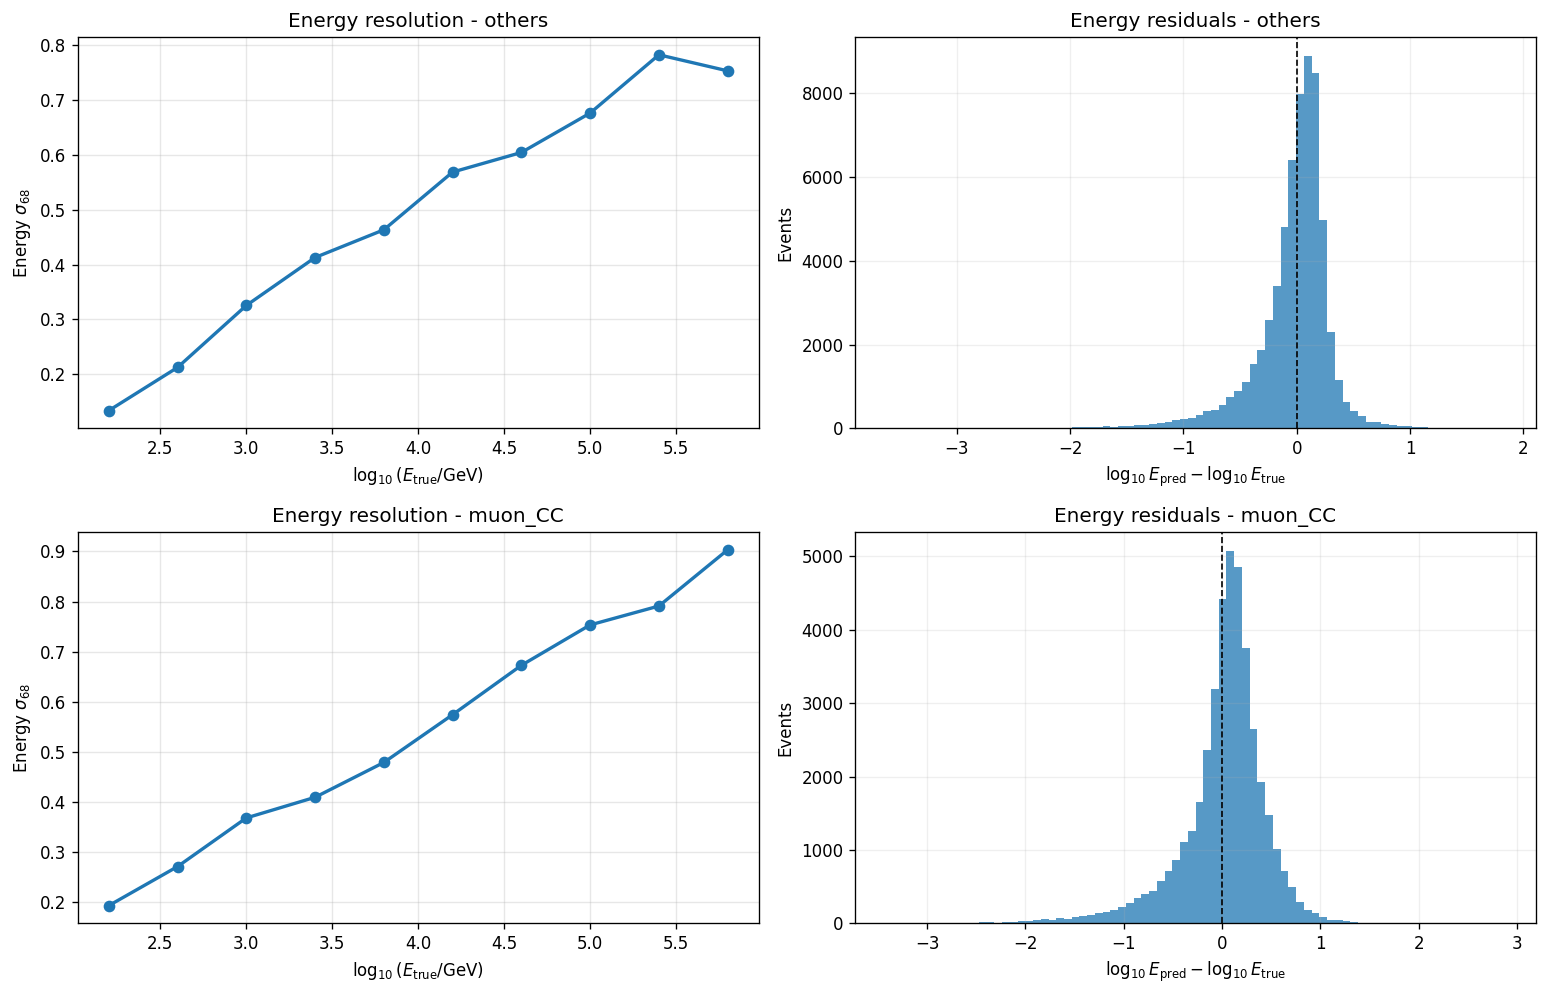

In [4]:
plot_resolution_and_residual_groups(
    energy_df,
    class_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


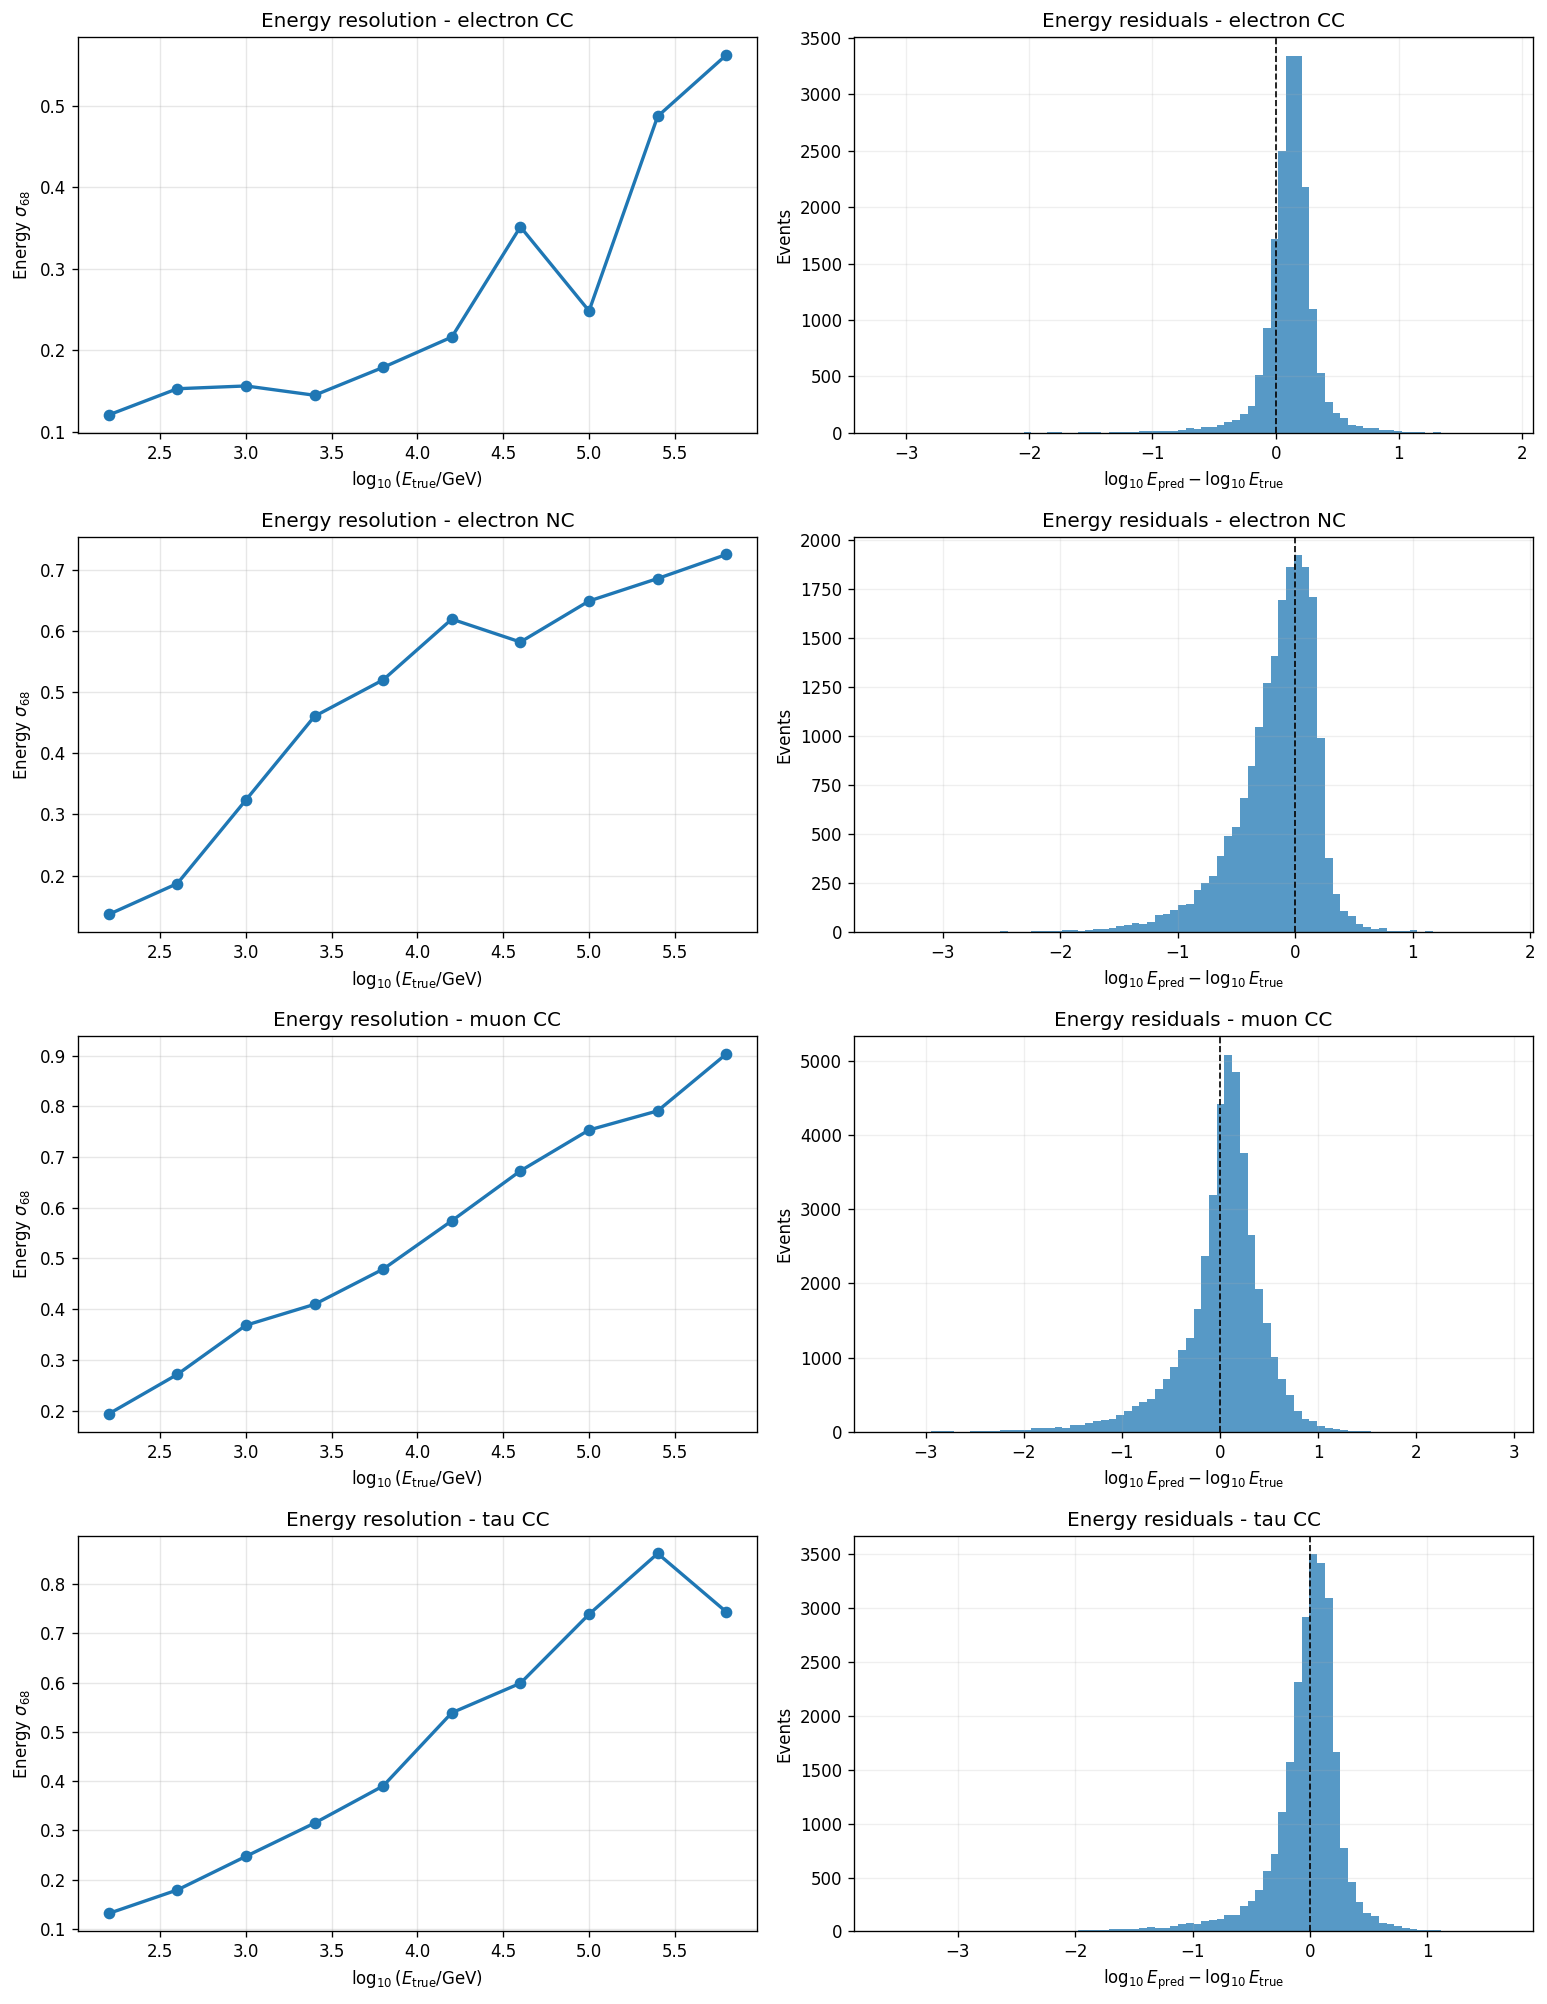

In [5]:
plot_resolution_and_residual_groups(
    energy_df,
    pid_interaction_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


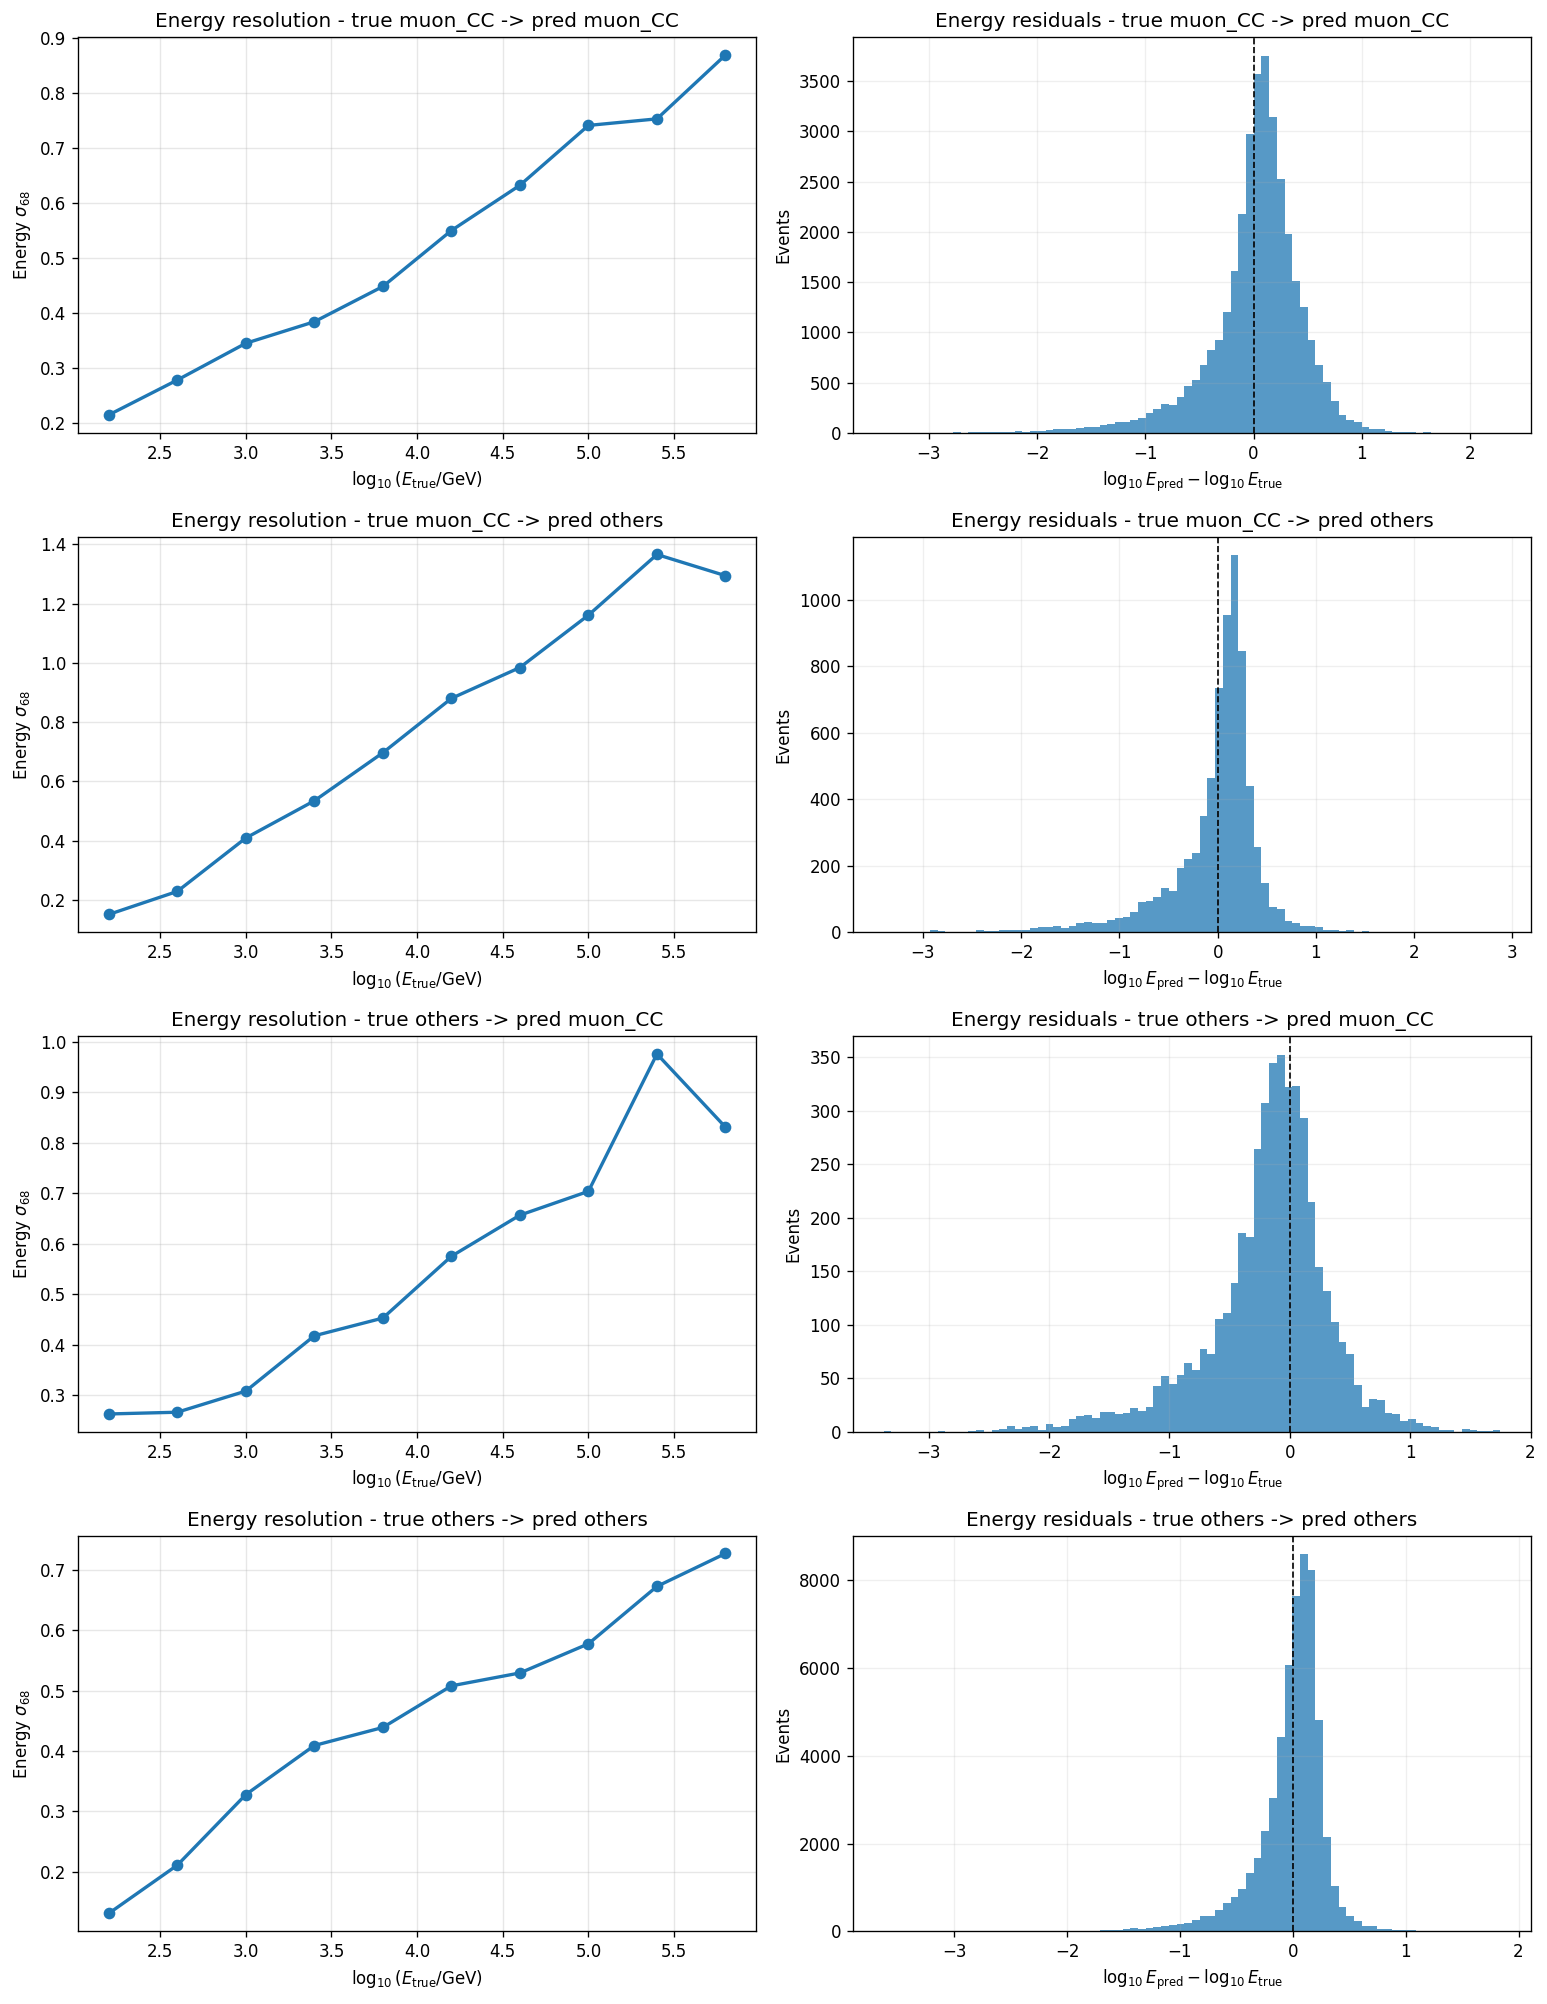

In [6]:
plot_resolution_and_residual_groups(
    energy_df,
    confusion_route_grouped_frames(energy_df),
    residual_col="energy_residual_log10",
    y_label=r"Energy $\sigma_{68}$",
    residual_xlabel=r"$\log_{10}E_\mathrm{pred}-\log_{10}E_\mathrm{true}$",
    title_prefix="Energy",
    color="tab:blue",
)


## Section 3 - Zenith


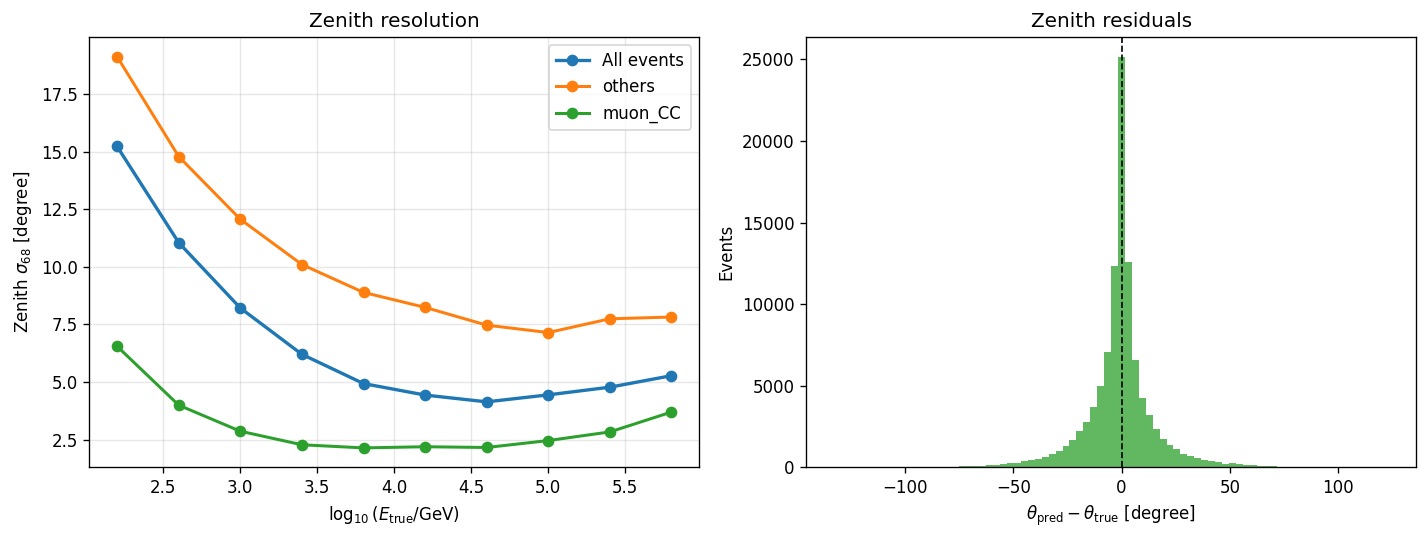

In [7]:
zenith_residual_col = "zenith_residual_zenith_degree" if "zenith_residual_zenith_degree" in df.columns else "residual_zenith_degree"
zenith_cols = ["true_log10_energy", zenith_residual_col, true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
zenith_df = df[[col for col in zenith_cols if col in df.columns]].dropna().copy()
zenith_df = zenith_df.rename(columns={zenith_residual_col: "zenith_residual_degree"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(zenith_df, "true_log10_energy", "zenith_residual_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in zenith_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "zenith_residual_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Zenith $\sigma_{68}$ [degree]")
axes[0].set_title("Zenith resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(zenith_df["zenith_residual_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:green")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Zenith residuals")
fig.tight_layout()
plt.show()


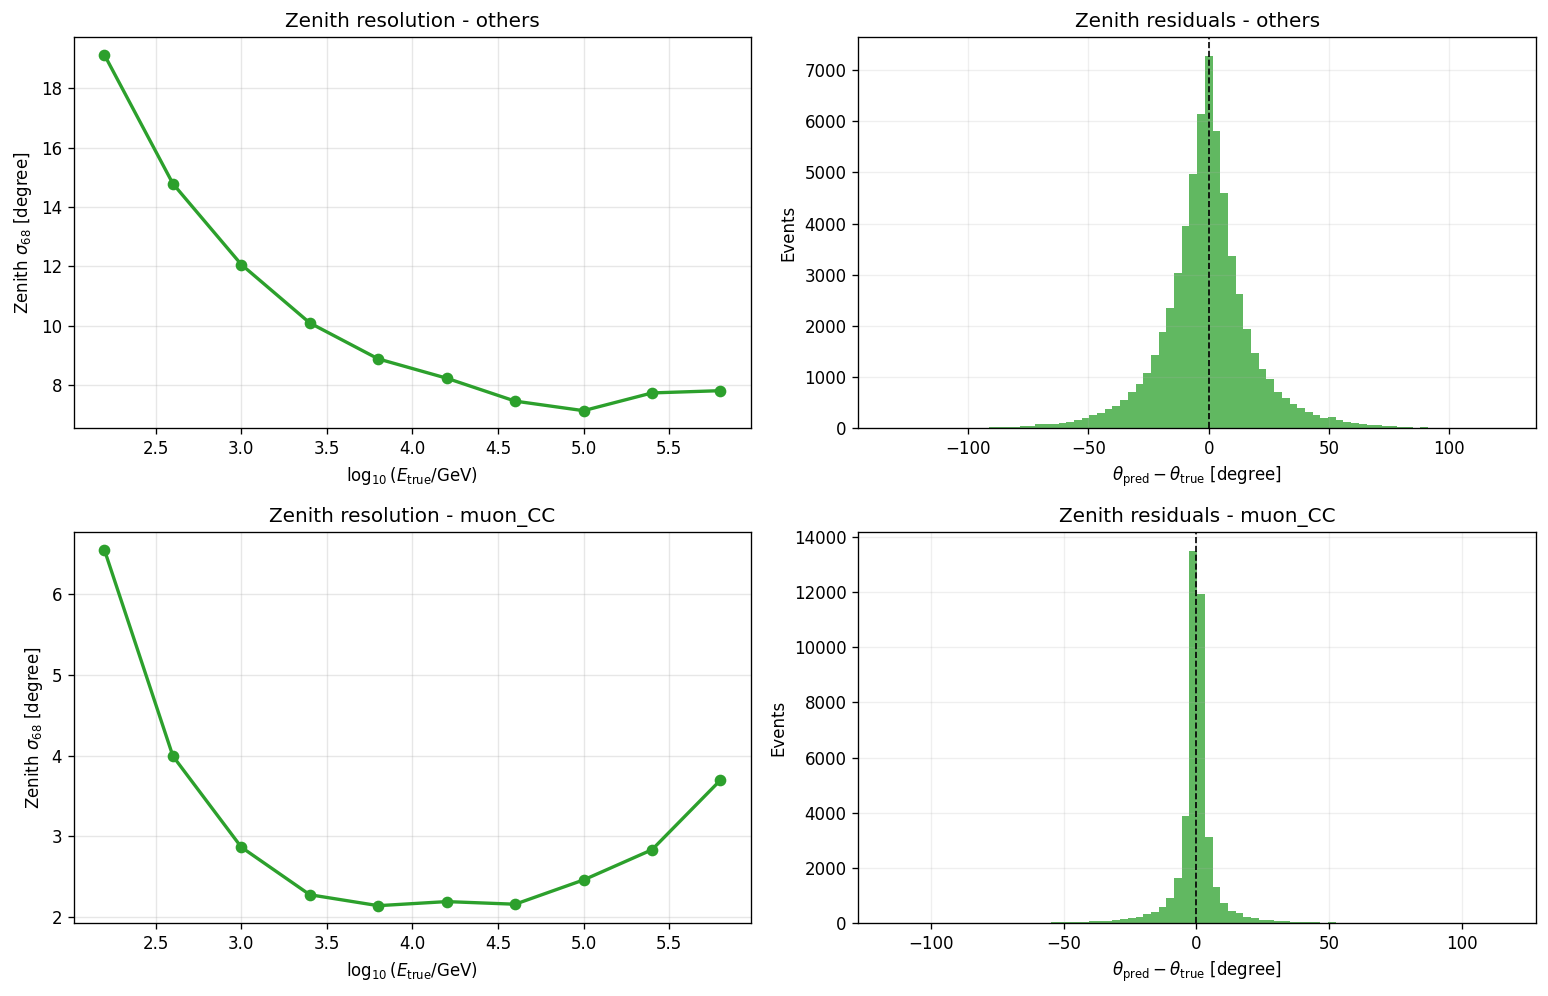

In [8]:
plot_resolution_and_residual_groups(
    zenith_df,
    class_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


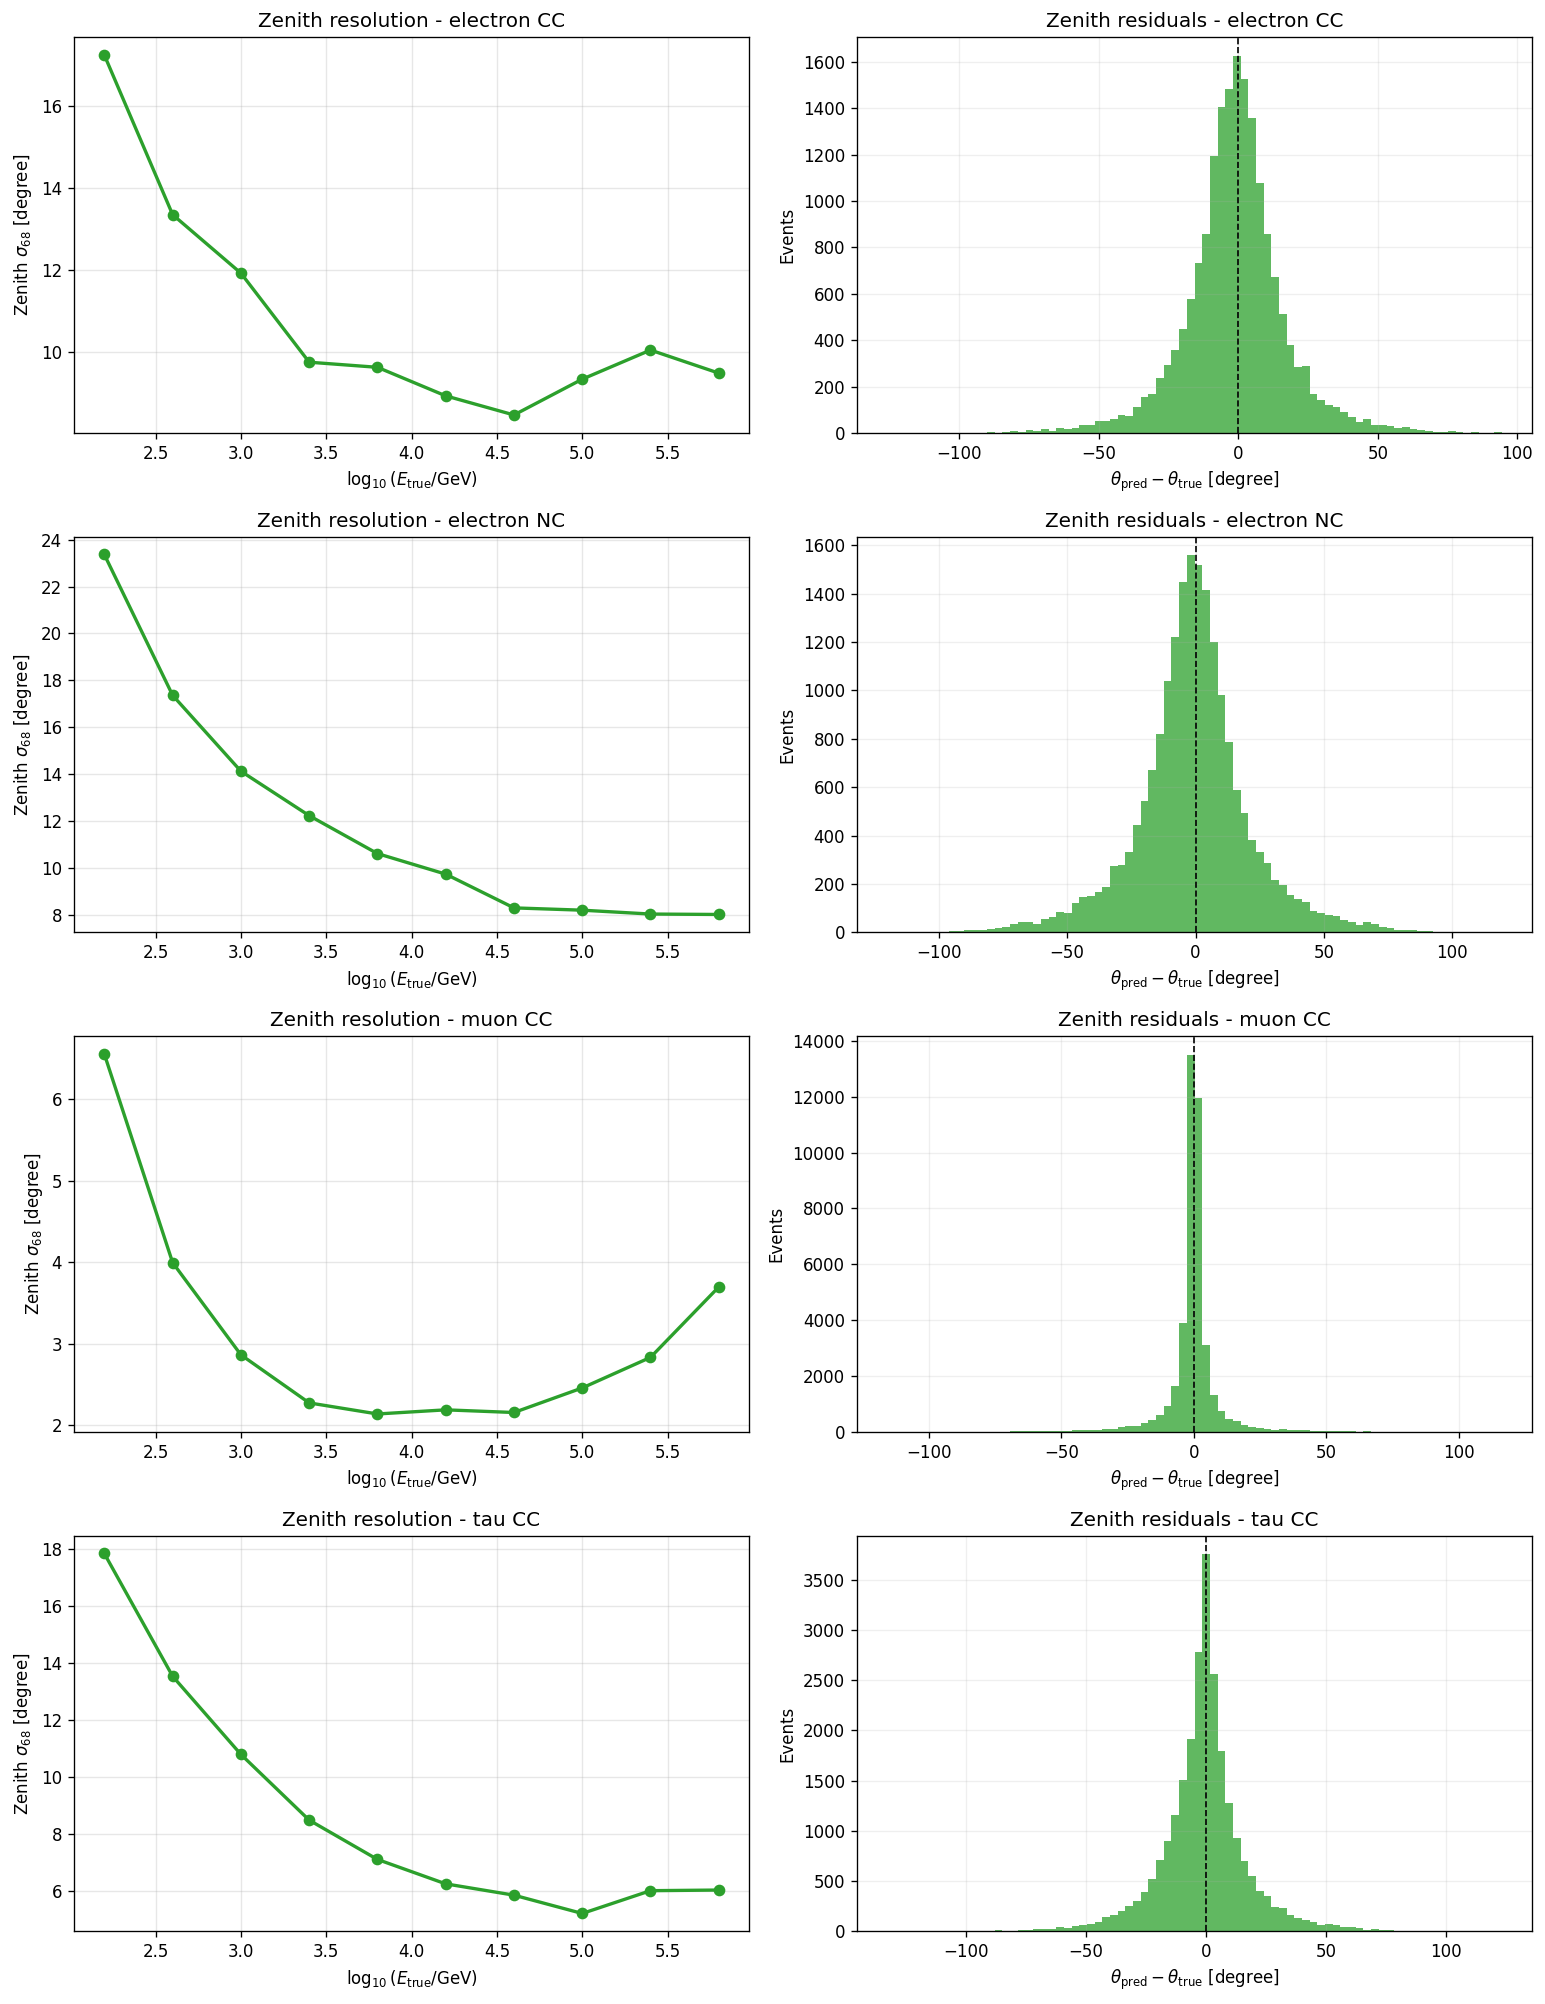

In [9]:
plot_resolution_and_residual_groups(
    zenith_df,
    pid_interaction_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


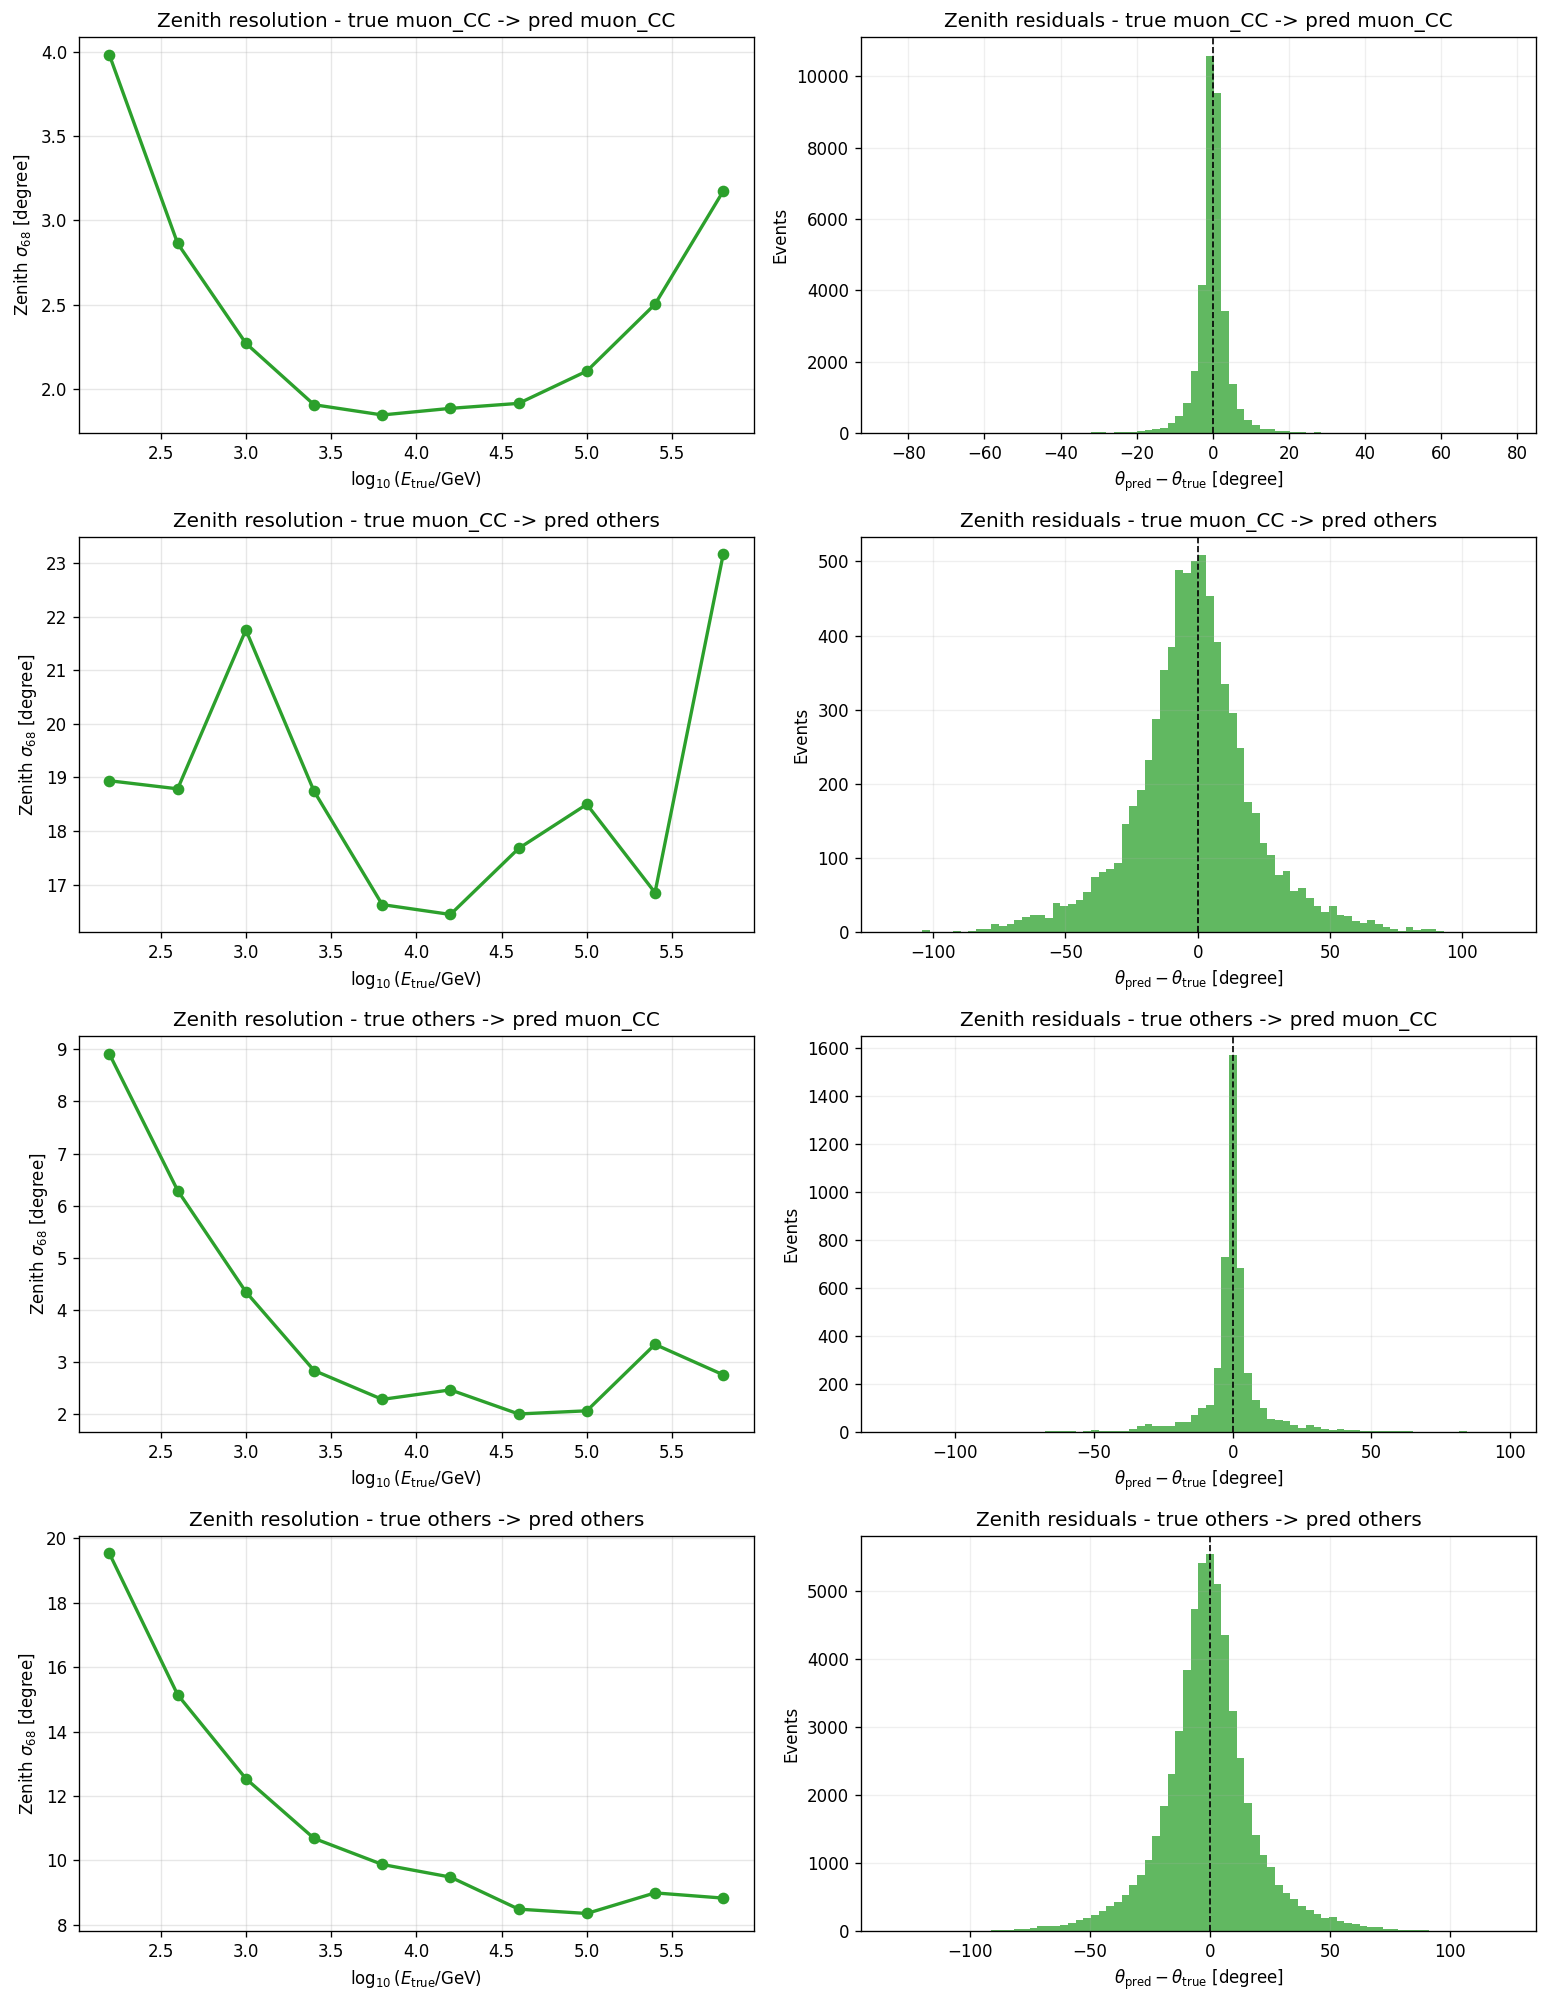

In [10]:
plot_resolution_and_residual_groups(
    zenith_df,
    confusion_route_grouped_frames(zenith_df),
    residual_col="zenith_residual_degree",
    y_label=r"Zenith $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\theta_\mathrm{pred}-\theta_\mathrm{true}$ [degree]",
    title_prefix="Zenith",
    color="tab:green",
)


## Section 4 - Azimuth


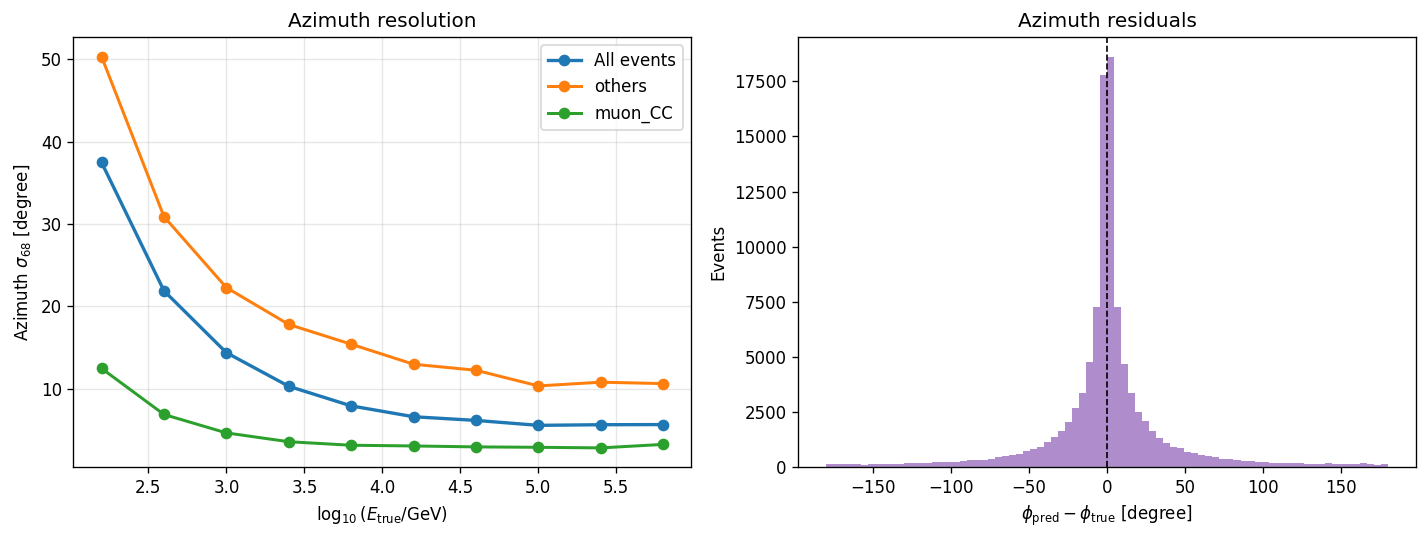

In [11]:
azimuth_residual_col = "azimuth_residual_azimuth_degree" if "azimuth_residual_azimuth_degree" in df.columns else "residual_azimuth_degree"
azimuth_cols = ["true_log10_energy", azimuth_residual_col, true_class_col, analysis_group_col, pid_interaction_exact_col, confusion_route_col]
azimuth_df = df[[col for col in azimuth_cols if col in df.columns]].dropna().copy()
azimuth_df = azimuth_df.rename(columns={azimuth_residual_col: "azimuth_residual_degree"})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6))
overall = binned_sigma(azimuth_df, "true_log10_energy", "azimuth_residual_degree", bins)
axes[0].plot(overall["bin_center"], overall["sigma68"], marker="o", linewidth=2, label="All events")
for label, group in azimuth_df.groupby(true_class_col, sort=True):
    table = binned_sigma(group, "true_log10_energy", "azimuth_residual_degree", bins)
    axes[0].plot(table["bin_center"], table["sigma68"], marker="o", linewidth=1.8, label=class_label(label))
axes[0].set_xlabel(r"$\log_{10}(E_\mathrm{true}/\mathrm{GeV})$")
axes[0].set_ylabel(r"Azimuth $\sigma_{68}$ [degree]")
axes[0].set_title("Azimuth resolution")
axes[0].grid(True, alpha=0.3)
axes[0].legend()

axes[1].hist(azimuth_df["azimuth_residual_degree"], bins=80, histtype="stepfilled", alpha=0.75, color="tab:purple")
axes[1].axvline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_xlabel(r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]")
axes[1].set_ylabel("Events")
axes[1].set_title("Azimuth residuals")
fig.tight_layout()
plt.show()


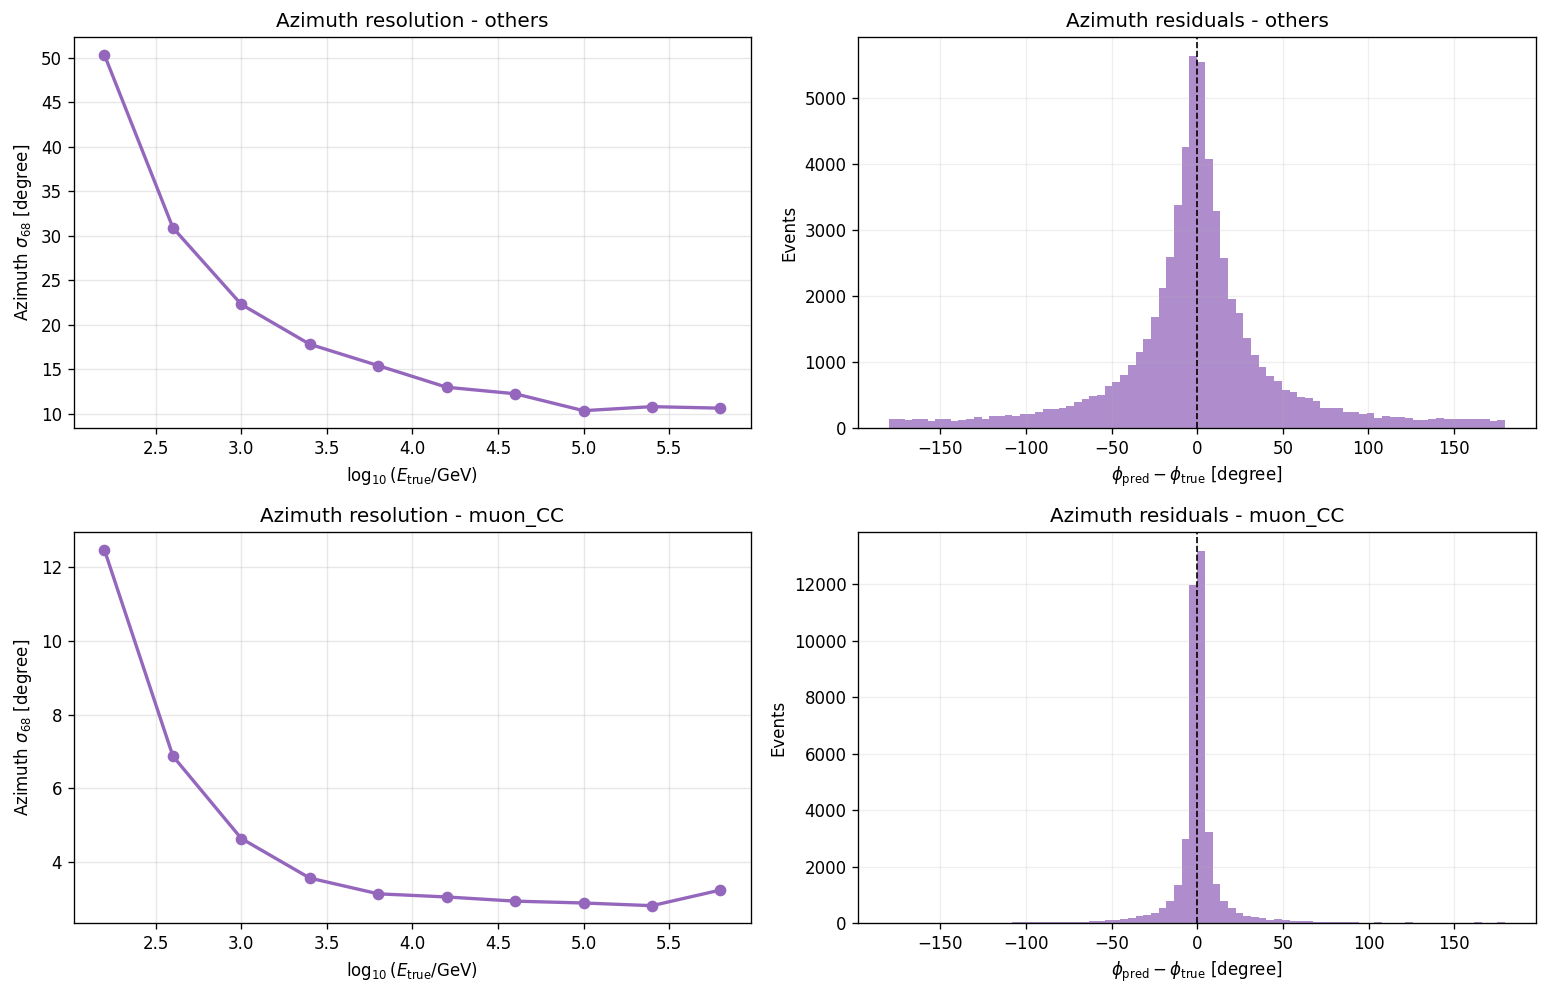

In [12]:
plot_resolution_and_residual_groups(
    azimuth_df,
    class_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


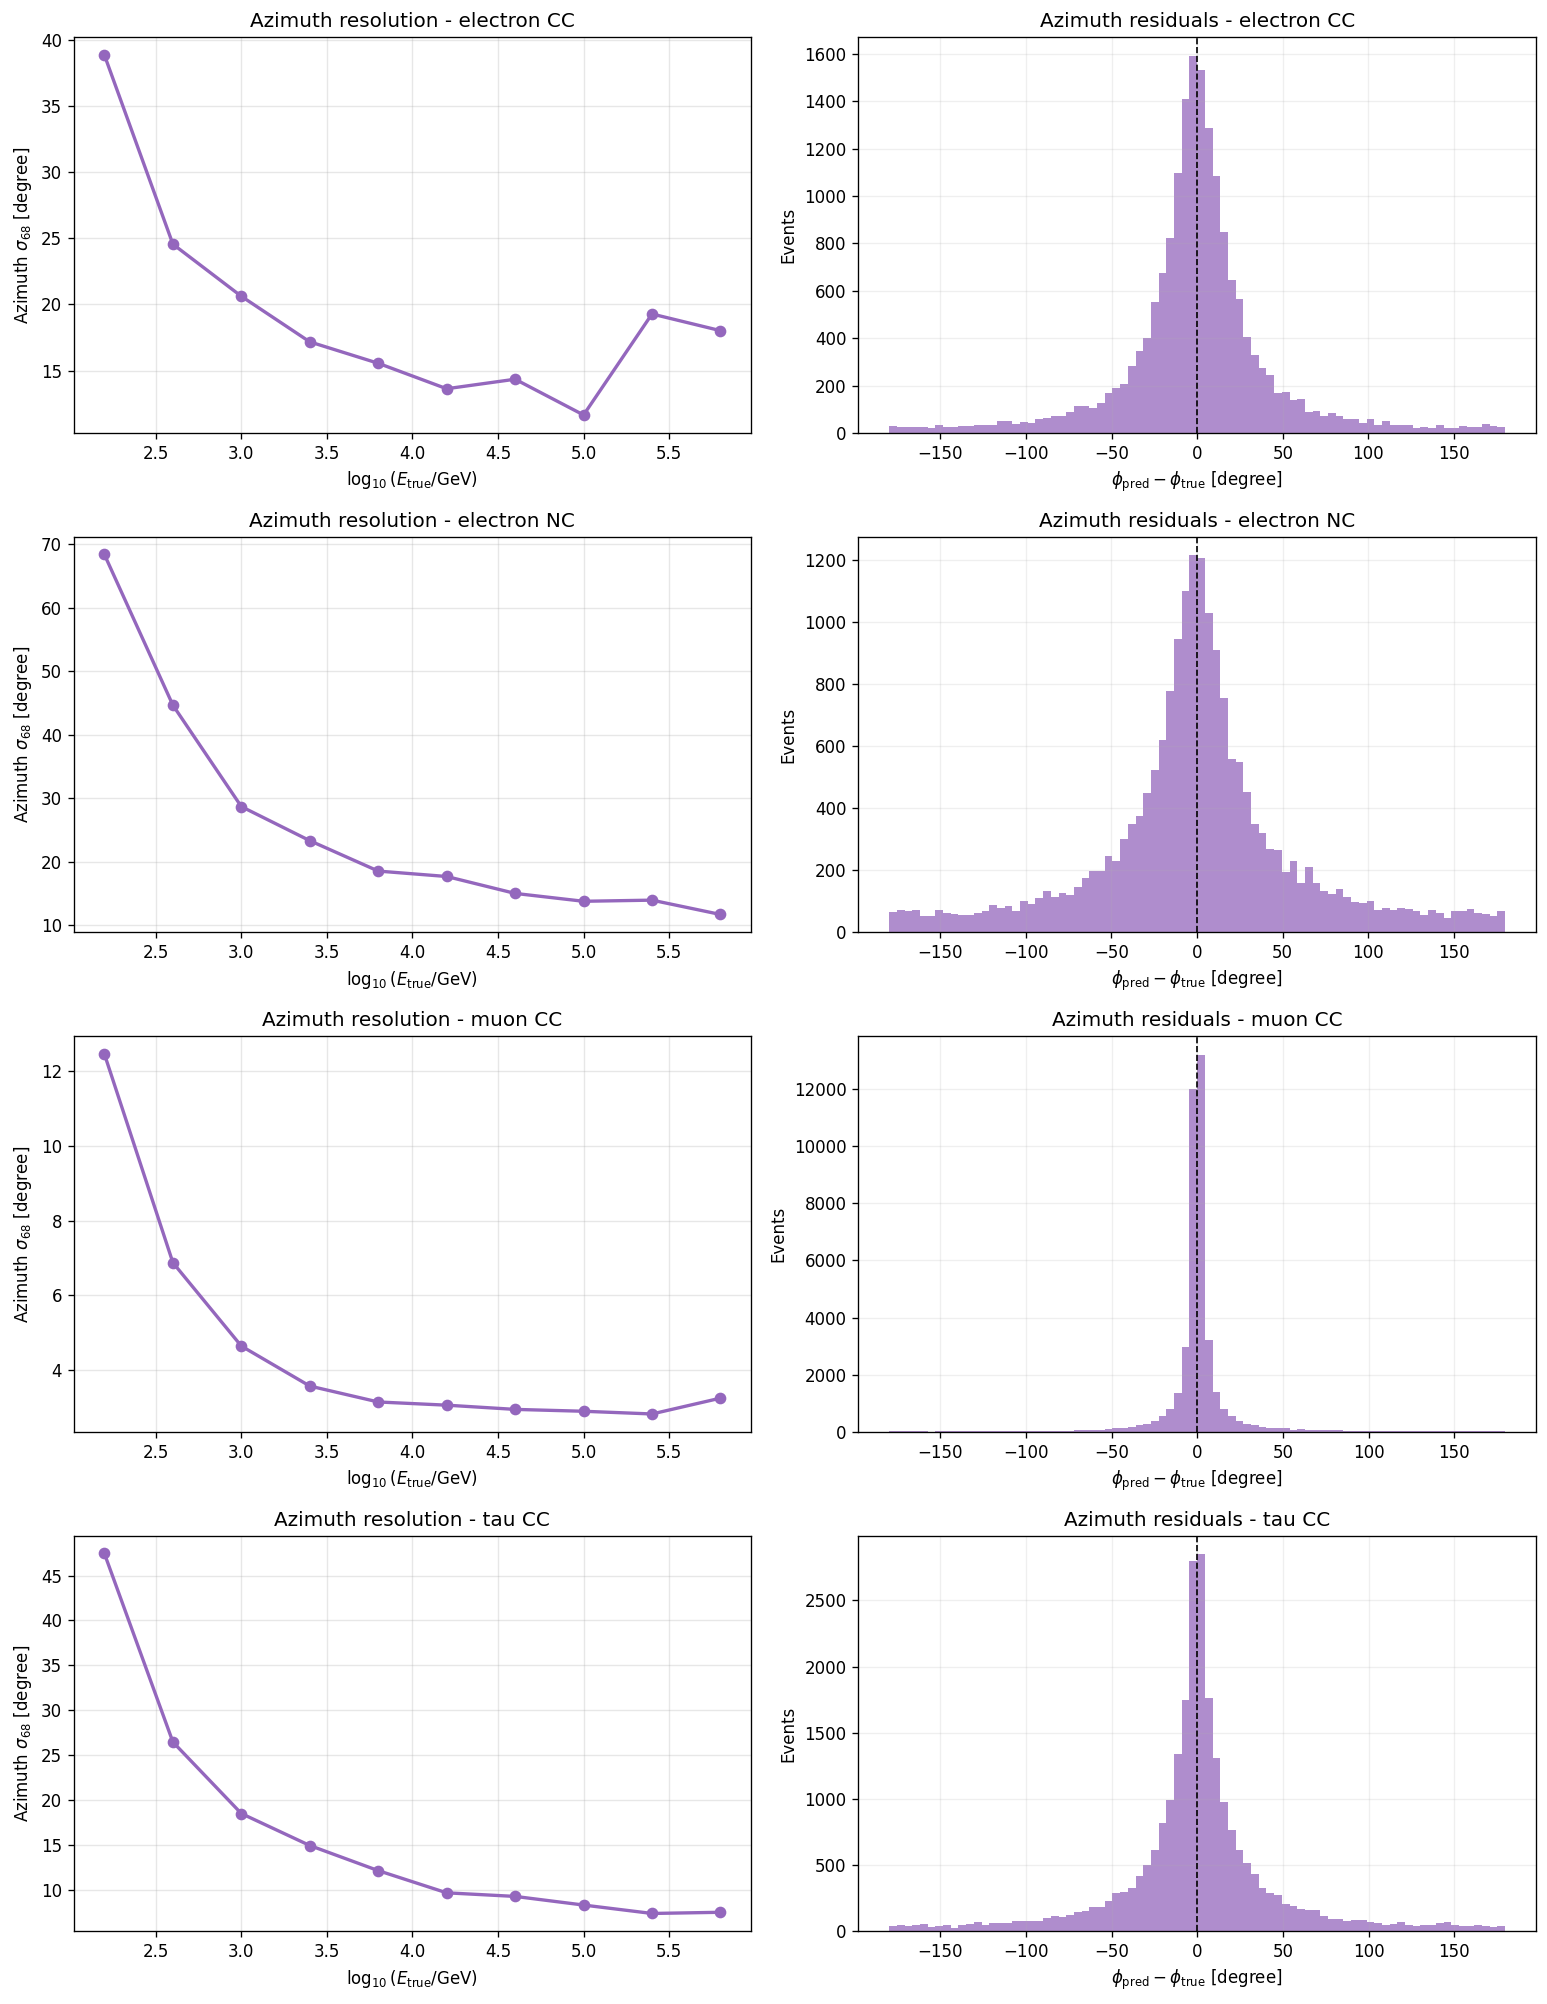

In [13]:
plot_resolution_and_residual_groups(
    azimuth_df,
    pid_interaction_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


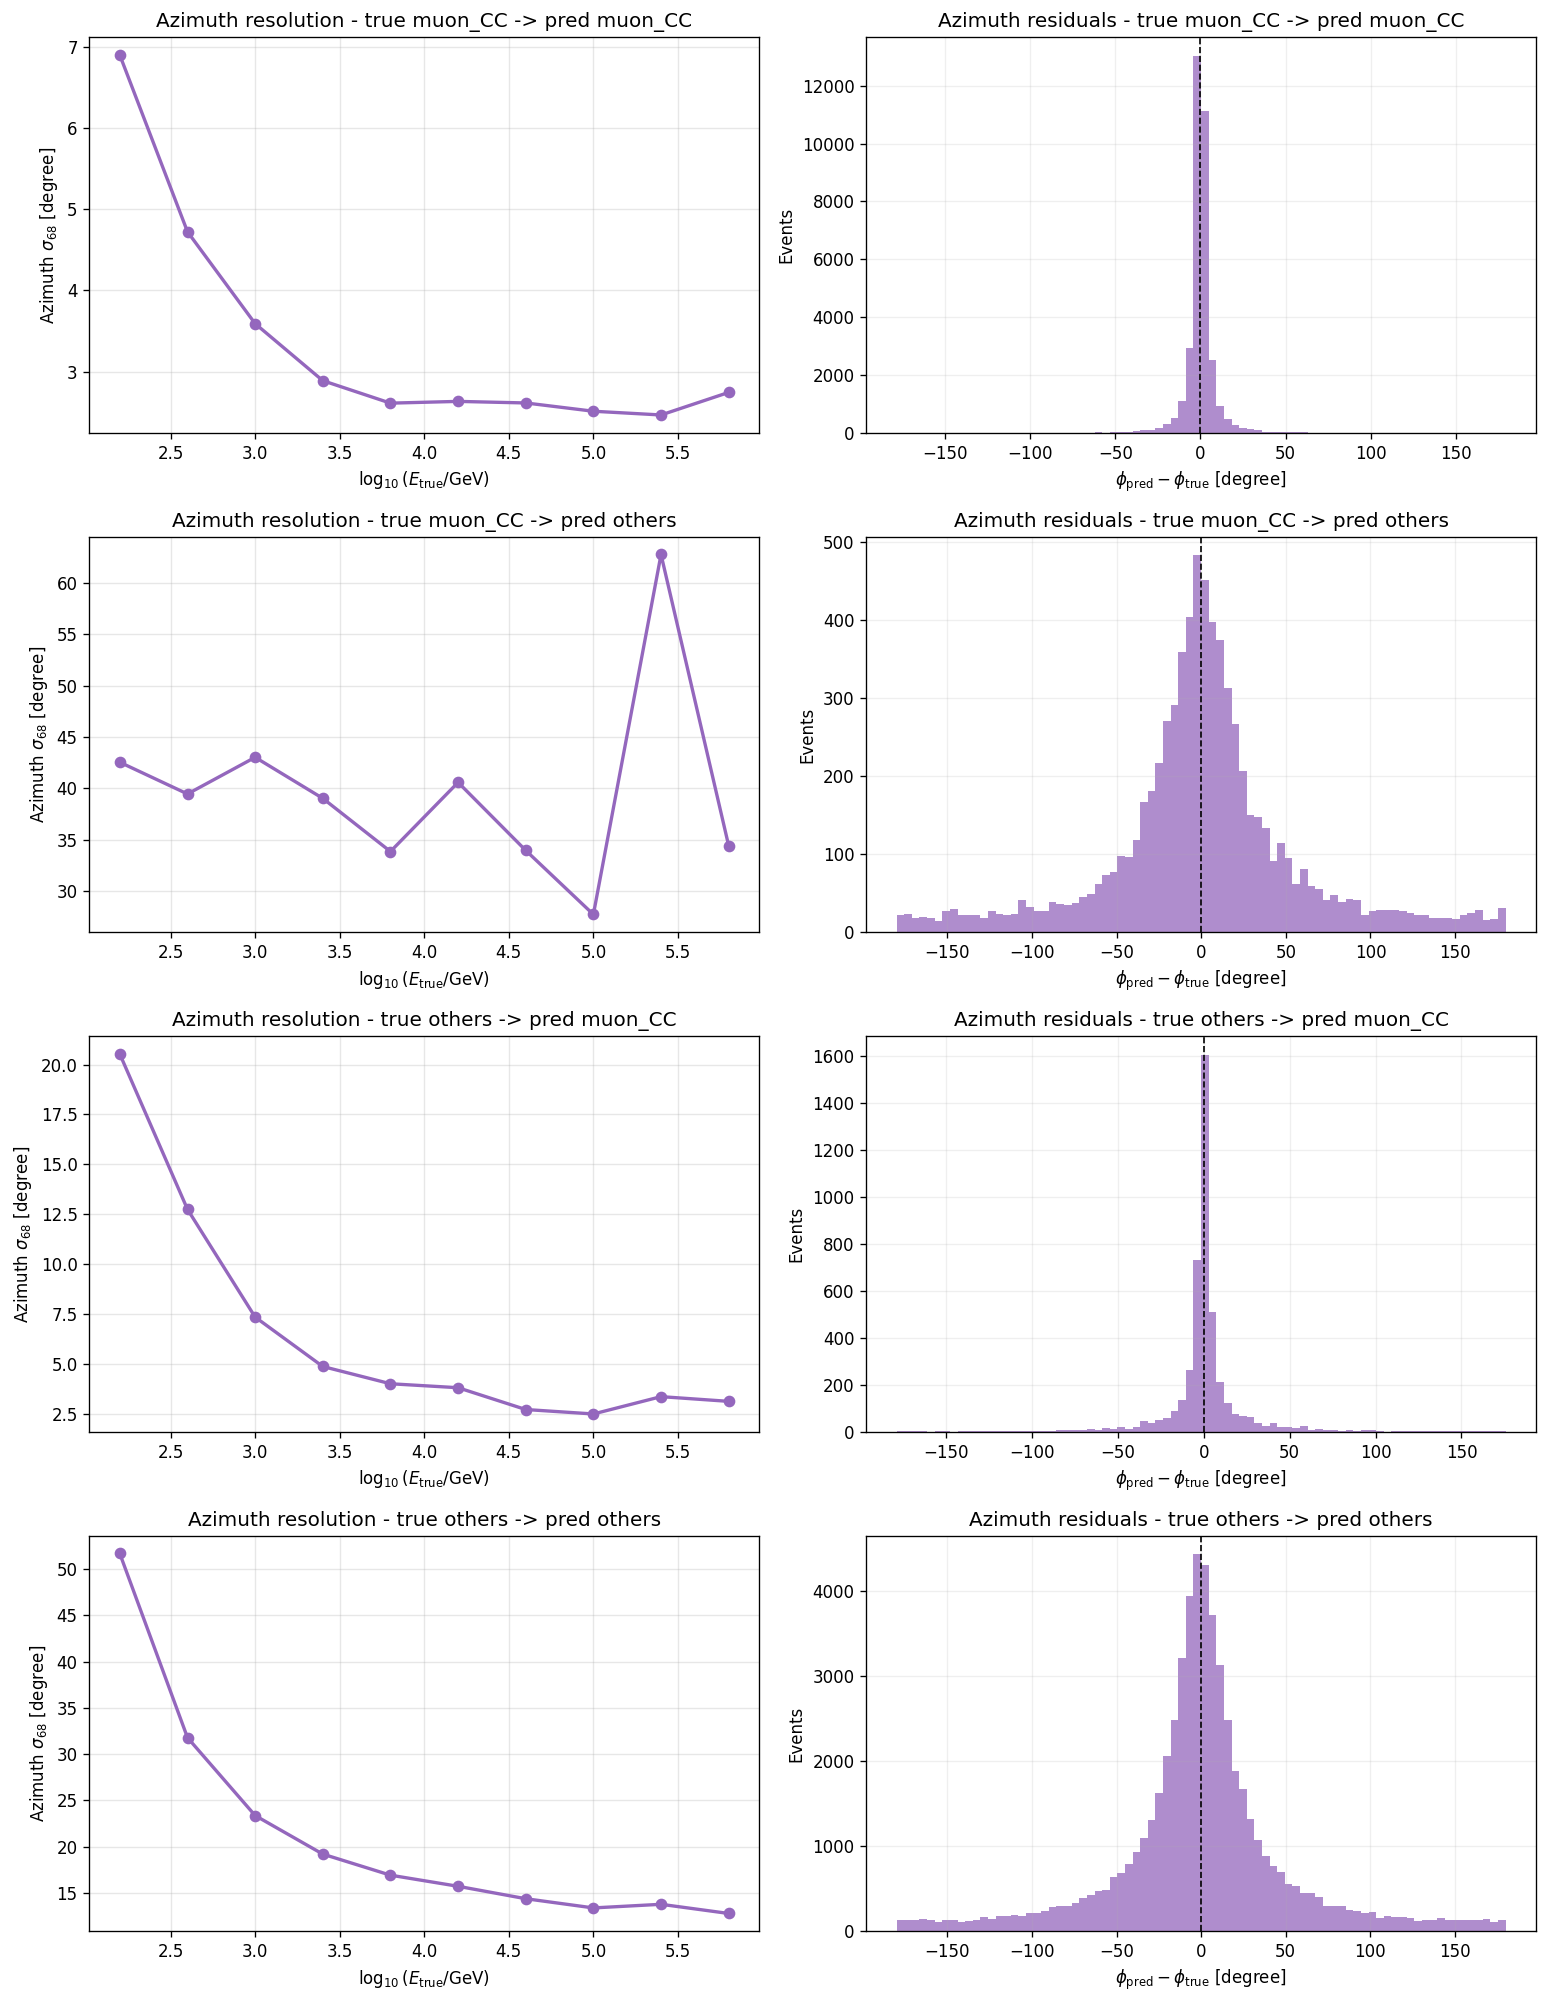

In [14]:
plot_resolution_and_residual_groups(
    azimuth_df,
    confusion_route_grouped_frames(azimuth_df),
    residual_col="azimuth_residual_degree",
    y_label=r"Azimuth $\sigma_{68}$ [degree]",
    residual_xlabel=r"$\phi_\mathrm{pred}-\phi_\mathrm{true}$ [degree]",
    title_prefix="Azimuth",
    color="tab:purple",
)


## Section 5 - Opening Angle


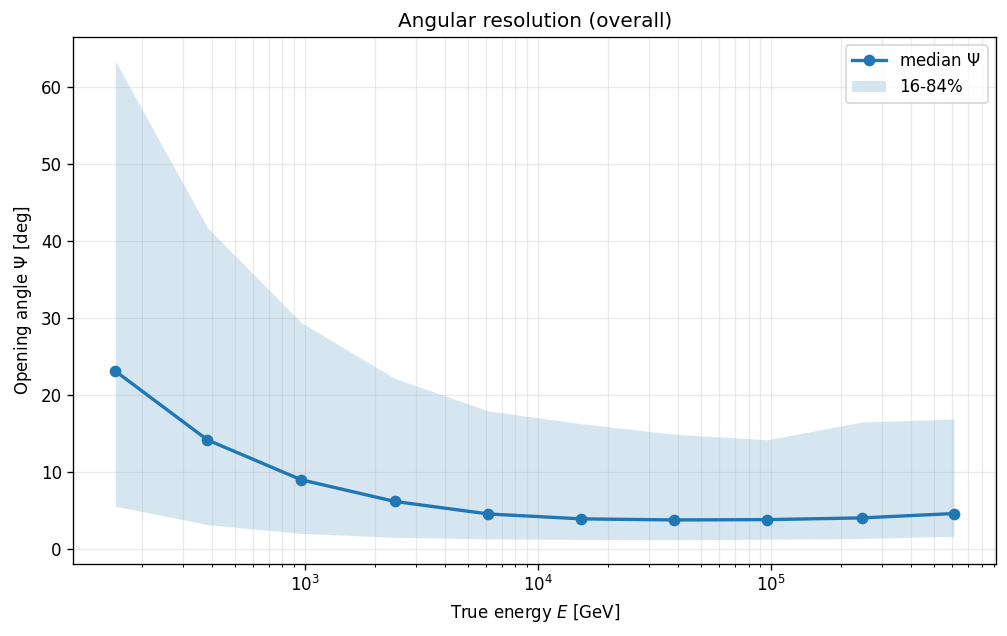

,bin_center_energy,count,median_psi,p16,p84
0,153.748285,39319,23.072390,5.533926,63.372091
1,381.841696,24506,14.136983,3.136727,41.706888
2,964.139383,14901,8.959821,1.989568,29.374111
3,2430.483885,9397,6.145500,1.485331,22.125904
4,6122.121735,6166,4.521225,1.284909,17.901778
5,15315.467128,4005,3.883723,1.206366,16.247893
6,38484.495116,2714,3.744220,1.185312,14.880746
7,96183.666761,1728,3.785668,1.232557,14.155827
8,245608.697863,1149,4.009491,1.339785,16.464170
9,609363.086389,752,4.577088,1.627529,16.858004


In [15]:
def opening_angle_deg(theta_true, phi_true, theta_pred, phi_pred):
    cos_delta = (
        np.sin(theta_true) * np.sin(theta_pred) * np.cos(phi_true - phi_pred)
        + np.cos(theta_true) * np.cos(theta_pred)
    )
    return np.degrees(np.arccos(np.clip(cos_delta, -1.0, 1.0)))

zen_true = "zenith_true_zenith_radian" if "zenith_true_zenith_radian" in df.columns else "true_zenith_radian"
zen_pred = "zenith_pred_zenith_radian" if "zenith_pred_zenith_radian" in df.columns else "pred_zenith_radian"
azi_true = "azimuth_true_azimuth_radian" if "azimuth_true_azimuth_radian" in df.columns else "true_azimuth_radian"
azi_pred = "azimuth_pred_azimuth_radian" if "azimuth_pred_azimuth_radian" in df.columns else "pred_azimuth_radian"

opening_cols = ["true_energy", "true_log10_energy", true_class_col, analysis_group_col, pid_interaction_exact_col, zen_true, zen_pred, azi_true, azi_pred]
opening_df = df[opening_cols].dropna().copy()
opening_df["opening_angle_degree"] = opening_angle_deg(opening_df[zen_true], opening_df[azi_true], opening_df[zen_pred], opening_df[azi_pred])

opening_df["energy_bin"] = pd.cut(opening_df["true_log10_energy"], bins=bins, include_lowest=True)
opening_summary = (
    opening_df.groupby("energy_bin", observed=True)
    .agg(
        bin_center_log10=("true_log10_energy", "mean"),
        count=("opening_angle_degree", "size"),
        median_psi=("opening_angle_degree", "median"),
        p16=("opening_angle_degree", lambda x: np.percentile(x, 16)),
        p84=("opening_angle_degree", lambda x: np.percentile(x, 84)),
    )
    .reset_index(drop=True)
)
opening_summary = opening_summary[opening_summary["count"] > 0].copy()
opening_summary["bin_center_energy"] = 10 ** opening_summary["bin_center_log10"]

fig, ax = plt.subplots(figsize=(8.5, 5.4))
ax.plot(
    opening_summary["bin_center_energy"], opening_summary["median_psi"],
    marker="o", linewidth=2, color="tab:blue", label=r"median $\Psi$"
)
ax.fill_between(
    opening_summary["bin_center_energy"], opening_summary["p16"], opening_summary["p84"],
    color="tab:blue", alpha=0.18, linewidth=0, label="16-84%"
)
ax.set_xscale("log")
ax.set_xlabel(r"True energy $E$ [GeV]")
ax.set_ylabel(r"Opening angle $\Psi$ [deg]")
ax.set_title("Angular resolution (overall)")
ax.grid(True, alpha=0.25, which="both")
ax.legend()
fig.tight_layout()
plt.show()

opening_summary[["bin_center_energy", "count", "median_psi", "p16", "p84"]]
